In [1]:
%pip install qiskit qiskit-aer ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import silhouette_score, calinski_harabasz_score, mean_squared_error

# Qiskit — simulación cuántica real con Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import zz_feature_map

warnings.filterwarnings('ignore')
from IPython.display import display

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
os.environ.setdefault('OMP_NUM_THREADS',    '1')

RANDOM_STATE = 42
N_RUNS       = 10      # repeticiones para análisis estadístico (punto 5)
np.random.seed(RANDOM_STATE)
np.set_printoptions(precision=5, suppress=True)
results_all = []   # acumula TODOS los runs para estadística

## 1. Kernels Cuánticos — Simulación Real con Qiskit Statevector

> **Corrección metodológica (Punto 1):** En la versión anterior los kernels se calculaban
> con álgebra lineal pura en NumPy (`dot(X,X.T)²`), que es computación clásica disfrazada.
> Aquí **cada kernel entry se obtiene simulando circuitos cuánticos reales** usando
> `qiskit.quantum_info.Statevector`, que implementa la mecánica cuántica exacta.
>
> La equivalencia matemática entre ambas implementaciones es verificable (ver celda de validación),
> pero la diferencia es fundamental: con Statevector estamos ejecutando simulación cuántica
> que escalaría a hardware cuántico real.

In [3]:
# ── Kernel 1: Angle Encoding ─────────────────────────────────────────────
# Codifica cada feature como ángulo de rotación RY en un qubit separado.
# |ψ(x)⟩ = ⊗ᵢ RY(xᵢ)|0⟩
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = ∏ᵢ cos²((xᵢ-zᵢ)/2)

def build_angle_circuit(x):
    """Circuito de Angle Encoding: un qubit RY por feature."""
    d = len(x)
    qc = QuantumCircuit(d)
    for i, angle in enumerate(x):
        qc.ry(float(angle), i)
    return qc

def angle_kernel_matrix(X):
    """
    Matriz de kernel de Angle Encoding usando Statevector de Qiskit.
    Complejidad: O(n² · 2^d) — simulación cuántica exacta.
    """
    n = len(X)
    # Precalcular todos los statevectors (una simulación por muestra)
    svs = [Statevector(build_angle_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 2: Amplitude Encoding ────────────────────────────────────────────
# Codifica el vector normalizado directamente como amplitudes del estado cuántico.
# |ψ(x)⟩ = Σᵢ xᵢ|i⟩  (requiere ||x||=1)
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = |x·z|²

def build_amplitude_circuit(x):
    """Circuito de Amplitude Encoding: prepare_state sobre log₂(d) qubits."""
    n_qubits = int(np.ceil(np.log2(len(x))))
    qc = QuantumCircuit(n_qubits)
    qc.prepare_state(x.tolist())
    return qc

def amplitude_kernel_matrix(X):
    """
    Matriz de kernel de Amplitude Encoding usando Statevector de Qiskit.
    X debe estar normalizado (norma L2 = 1 por fila).
    """
    n = len(X)
    svs = [Statevector(build_amplitude_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 3: ZZ Feature Map (IQP Kernel) ───────────────────────────────────
# Kernel cuántico con entrelazamiento ZZ — captura correlaciones entre features
# que los kernels de producto no pueden detectar.
# Usa la codificación IQP estándar (Havlíček et al. 2019).

def build_zz_circuit(x, n_qubits=4, reps=2):
    """Circuito ZZ Feature Map con entrelazamiento entre qubits."""
    fmap = zz_feature_map(feature_dimension=n_qubits, reps=reps)
    return fmap.assign_parameters(x)

def zz_kernel_matrix(X, n_qubits=4, reps=2):
    """
    Kernel IQP (ZZ Feature Map) con simulación Statevector.
    Requiere exactamente n_qubits features como entrada.
    """
    n = len(X)
    svs = [Statevector(build_zz_circuit(xi, n_qubits, reps)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K

print("Kernels cuánticos definidos:")
print("  1. Angle Encoding   — RY gates, 8 qubits")
print("  2. Amplitude Encoding — prepare_state, 3 qubits")
print("  3. ZZ Feature Map   — IQP kernel con entrelazamiento, 4 qubits")

Kernels cuánticos definidos:
  1. Angle Encoding   — RY gates, 8 qubits
  2. Amplitude Encoding — prepare_state, 3 qubits
  3. ZZ Feature Map   — IQP kernel con entrelazamiento, 4 qubits


### 1.1 Validación: Equivalencia y Diferencia con la Implementación Clásica

Es importante establecer explícitamente la diferencia entre la implementación anterior
y la nueva basada en Statevector.

In [4]:
# Implementación ANTERIOR (clásica, incorrecta como "quantum"):
def old_angle_kernel_numpy(X):
    """Versión anterior — álgebra lineal NumPy pura, NO es simulación cuántica."""
    n, d = X.shape
    K = np.ones((n, n))
    for i in range(n):
        diff = (X[i] - X) / 2.0
        K[i,:] = np.prod(np.cos(diff)**2, axis=1)
    return K

# Prueba de equivalencia matemática
np.random.seed(0)
X_val = np.random.uniform(0, np.pi, (15, 4))

K_numpy   = old_angle_kernel_numpy(X_val)
K_qiskit  = angle_kernel_matrix(X_val)
max_diff  = np.max(np.abs(K_numpy - K_qiskit))

print("=== VALIDACIÓN DE KERNELS ===")
print(f"Diferencia máxima NumPy vs Qiskit Statevector: {max_diff:.2e}")
print(f"Matemáticamente equivalentes (tol=1e-10): {np.allclose(K_numpy, K_qiskit, atol=1e-10)}")
print()
print("DIFERENCIA CLAVE:")
print("  - NumPy:    operaciones matriciales clásicas en CPU.")
print("  - Qiskit:   simula el estado cuántico completo |ψ⟩ en espacio de Hilbert 2^d,")
print("              y calcula el solapamiento ⟨ψ(x)|ψ(z)⟩ via mecánica cuántica exacta.")
print("              Esta implementación escala directamente a hardware cuántico real.")

# Verificar que los kernels son semidefinidos positivos (requisito para SVM/t-SNE válido)
eigvals_angle = np.linalg.eigvalsh(K_qiskit)
print(f"\nKernel Angle PSD (min eigenvalue ≥ 0): {eigvals_angle.min():.6f} — {'OK' if eigvals_angle.min() >= -1e-8 else 'FALLO'}")

=== VALIDACIÓN DE KERNELS ===
Diferencia máxima NumPy vs Qiskit Statevector: 5.55e-16
Matemáticamente equivalentes (tol=1e-10): True

DIFERENCIA CLAVE:
  - NumPy:    operaciones matriciales clásicas en CPU.
  - Qiskit:   simula el estado cuántico completo |ψ⟩ en espacio de Hilbert 2^d,
              y calcula el solapamiento ⟨ψ(x)|ψ(z)⟩ via mecánica cuántica exacta.
              Esta implementación escala directamente a hardware cuántico real.

Kernel Angle PSD (min eigenvalue ≥ 0): 0.068201 — OK


## 2. Carga del Dataset NATICUSdroid Android Permissions

In [5]:
naticusdroid = fetch_ucirepo(id=722)

X_full = naticusdroid.data.features
y_full = pd.factorize(naticusdroid.data.targets.values.ravel())[0]

print(f"Dataset completo: {X_full.shape[0]:,} muestras × {X_full.shape[1]} features")
print(f"Distribución de clases: {dict(zip(*np.unique(y_full, return_counts=True)))}")
print()
print("Clases originales:", np.unique(naticusdroid.data.targets.values.ravel()))

Dataset completo: 29,332 muestras × 86 features
Distribución de clases: {np.int64(0): np.int64(14632), np.int64(1): np.int64(14700)}

Clases originales: [0 1]


## 3. Preprocesamiento: Selección de Features y Submuestreo Estratificado

> **Decisión de diseño documentada (Punto 6):** Los métodos de kernel cuántico tienen
> complejidad O(n²) en número de muestras. Para garantizar condiciones de comparación
> **idénticas** entre todos los métodos (clásico y cuántico), **todos los métodos
> utilizan exactamente el mismo subconjunto estratificado de n=500 muestras**.
> Esto elimina el sesgo de comparación de la versión anterior.

In [6]:
from sklearn.model_selection import train_test_split

# ── Selección de features con Chi-cuadrado ──────────────────────────────────
NUM_FEATURES = 8

selector = SelectKBest(chi2, k=NUM_FEATURES)
X_sel = selector.fit_transform(X_full, y_full)
selected_names = X_full.columns[selector.get_support(indices=True)].tolist()

print(f"Features originales: {X_full.shape[1]}  →  Seleccionadas: {NUM_FEATURES}")
print("Features seleccionadas por Chi²:")
for f in selected_names:
    print(f"  - {f}")

# ── Submuestreo estratificado ────────────────────────────────────────────────
N_SAMPLES = 500

_, X_sub, _, y_sub = train_test_split(
    X_sel, y_full,
    test_size=N_SAMPLES,
    stratify=y_full,
    random_state=RANDOM_STATE
)

print(f"\nSubmuestreo estratificado: {N_SAMPLES} muestras")
print(f"Distribución de clases en submuestra: {dict(zip(*np.unique(y_sub, return_counts=True)))}")
print("\n✓ TODOS los métodos (clásico y cuántico) usarán exactamente este subconjunto.")

Features originales: 86  →  Seleccionadas: 8
Features seleccionadas por Chi²:
  - android.permission.GET_TASKS
  - com.android.launcher.permission.INSTALL_SHORTCUT
  - android.permission.READ_PHONE_STATE
  - com.google.android.c2dm.permission.RECEIVE
  - android.permission.ACCESS_COARSE_LOCATION
  - android.permission.SYSTEM_ALERT_WINDOW
  - android.permission.RECEIVE_BOOT_COMPLETED
  - android.permission.ACCESS_FINE_LOCATION

Submuestreo estratificado: 500 muestras
Distribución de clases en submuestra: {np.int64(0): np.int64(249), np.int64(1): np.int64(251)}

✓ TODOS los métodos (clásico y cuántico) usarán exactamente este subconjunto.


In [7]:
# ── Preprocesamiento consistente para todos los métodos ─────────────────────
X_raw = X_sub.copy()
y     = y_sub.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Amplitude Encoding: padding + normalización L2
def next_pow2(n): return 1 if n <= 1 else 2**math.ceil(math.log2(n))
amplitude_dim   = next_pow2(X_scaled.shape[1])   # 8 → 8 = 2³
n_system_qubits = int(math.log2(amplitude_dim))   # = 3

X_padded = np.zeros((len(X_scaled), amplitude_dim))
X_padded[:, :X_scaled.shape[1]] = X_scaled
X_amp = X_padded / np.linalg.norm(X_padded, axis=1, keepdims=True)

# Angle Encoding: escalar a [0, π]
X_angles = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_raw)

# ZZ Feature Map: PCA a 4 componentes + escalar a [0, π]
N_QUBITS_ZZ = 4
pca_zz   = PCA(n_components=N_QUBITS_ZZ, random_state=RANDOM_STATE)
X_pca_zz = pca_zz.fit_transform(X_scaled)
X_zz     = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca_zz)

# PCA Clásico para baseline t-SNE
N_PCA = 6
pca_classic   = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_pca_classic = pca_classic.fit_transform(X_scaled)

print("Preprocesamiento completado:")
print(f"  X_scaled  : {X_scaled.shape}  → Amplitude Encoding ({n_system_qubits} qubits)")
print(f"  X_angles  : {X_angles.shape}  → Angle Encoding (8 qubits)")
print(f"  X_zz      : {X_zz.shape}  → ZZ Feature Map ({N_QUBITS_ZZ} qubits)")
print(f"  X_pca_cl  : {X_pca_classic.shape}  → t-SNE Clásico (baseline)")

Preprocesamiento completado:
  X_scaled  : (500, 8)  → Amplitude Encoding (3 qubits)
  X_angles  : (500, 8)  → Angle Encoding (8 qubits)
  X_zz      : (500, 4)  → ZZ Feature Map (4 qubits)
  X_pca_cl  : (500, 6)  → t-SNE Clásico (baseline)


## 4. Funciones Auxiliares

In [8]:
def run_tsne_from_kernel(K, perplexity=30, seed=RANDOM_STATE):
    """t-SNE sobre matriz de kernel cuántica (precomputed distance)."""
    dist = np.sqrt(np.maximum(1.0 - K, 0.0))
    np.fill_diagonal(dist, 0.0)
    return TSNE(
        n_components=2, perplexity=perplexity,
        metric='precomputed', init='random',
        random_state=seed, n_jobs=1
    ).fit_transform(dist)

def compute_metrics(embedding, labels):
    return {
        'Silhouette' : silhouette_score(embedding, labels),
        'CH_Index'   : calinski_harabasz_score(embedding, labels),
    }

def plot_embedding(ax, emb, labels, title):
    sc = ax.scatter(emb[:,0], emb[:,1], c=labels,
                    cmap='viridis', edgecolors='k', alpha=0.7, s=15)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(True, linestyle='--', alpha=0.4)
    return sc

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 5. Análisis Estadístico con Múltiples Corridas

> **Corrección metodológica (Punto 5):** t-SNE es estocástico: diferentes semillas
> producen resultados distintos. Un único run con `random_state=42` **no es suficiente**
> para comparar métodos en investigación. Aquí ejecutamos **N_RUNS corridas con semillas
> distintas** y reportamos media ± desviación estándar de Silhouette y Calinski-Harabasz.
> Esto permite comparar con rigor estadístico.

In [9]:
# ── Precalcular matrices de kernel (solo 1 vez, son deterministas) ──────────
print("Calculando matrices de kernel cuántico (Qiskit Statevector)...")
print("  Este paso es determinista — no depende de la semilla de t-SNE.")

t0 = time.time()
K_angle     = angle_kernel_matrix(X_angles)
print(f"  Angle Encoding:    {time.time()-t0:.1f}s")

t0 = time.time()
K_amplitude = amplitude_kernel_matrix(X_amp)
print(f"  Amplitude Encoding:{time.time()-t0:.1f}s")

t0 = time.time()
K_zz        = zz_kernel_matrix(X_zz, n_qubits=N_QUBITS_ZZ)
print(f"  ZZ Feature Map:    {time.time()-t0:.1f}s")

# Verificar que todas las matrices son PSD
for name, K in [('Angle', K_angle), ('Amplitude', K_amplitude), ('ZZ', K_zz)]:
    ev = np.linalg.eigvalsh(K).min()
    status = 'OK' if ev >= -1e-6 else f'ADVERTENCIA: min_eig={ev:.2e}'
    print(f"  PSD check {name}: {status}")

print("\nKernels calculados. Iniciando análisis estadístico...")

Calculando matrices de kernel cuántico (Qiskit Statevector)...
  Este paso es determinista — no depende de la semilla de t-SNE.
  Angle Encoding:    0.9s
  Amplitude Encoding:2.1s
  ZZ Feature Map:    1.5s
  PSD check Angle: OK
  PSD check Amplitude: OK
  PSD check ZZ: OK

Kernels calculados. Iniciando análisis estadístico...


In [10]:
# ── Múltiples corridas de t-SNE para análisis estadístico ───────────────────
# La fuente de aleatoriedad es SOLO la inicialización de t-SNE (seed variable),
# no los kernels (que son deterministas).

SEEDS = [42 + i*17 for i in range(N_RUNS)]

method_configs = {
    'Classical t-SNE (PCA-6D)': {
        'type': 'classical',
        'X': X_pca_classic,
        'label': 'Classical\nt-SNE (PCA)'
    },
    'Quantum Angle Encoding (8Q)': {
        'type': 'quantum',
        'K': K_angle,
        'label': 'Angle\nEncoding (8Q)'
    },
    'Quantum Amplitude Encoding (3Q)': {
        'type': 'quantum',
        'K': K_amplitude,
        'label': 'Amplitude\nEncoding (3Q)'
    },
    'Quantum ZZ Feature Map (4Q)': {
        'type': 'quantum',
        'K': K_zz,
        'label': 'ZZ Feature\nMap (4Q)'
    },
}

# Ejecutar N_RUNS por método
run_records = []   # {method, seed, Silhouette, CH_Index, embedding}

for method_name, cfg in method_configs.items():
    sil_list, ch_list = [], []
    for seed in SEEDS:
        if cfg['type'] == 'classical':
            emb = TSNE(n_components=2, perplexity=30,
                       random_state=seed, n_jobs=1).fit_transform(cfg['X'])
        else:
            emb = run_tsne_from_kernel(cfg['K'], perplexity=30, seed=seed)

        m = compute_metrics(emb, y)
        sil_list.append(m['Silhouette'])
        ch_list.append(m['CH_Index'])

        run_records.append({
            'Método': method_name,
            'Semilla': seed,
            'Silhouette': m['Silhouette'],
            'CH_Index': m['CH_Index'],
            'embedding': emb   # guardamos solo el último para visualización
        })

    print(f"{method_name[:42]:<42}  "
          f"Sil={np.mean(sil_list):.4f}±{np.std(sil_list):.4f}  "
          f"CH={np.mean(ch_list):.1f}±{np.std(ch_list):.1f}")

df_runs = pd.DataFrame(run_records)
print("\nAnálisis estadístico completado.")

Classical t-SNE (PCA-6D)                    Sil=0.3275±0.0000  CH=269.5±0.0
Quantum Angle Encoding (8Q)                 Sil=0.1225±0.0166  CH=34.9±7.7
Quantum Amplitude Encoding (3Q)             Sil=0.1218±0.0112  CH=62.4±5.4
Quantum ZZ Feature Map (4Q)                 Sil=0.1213±0.0091  CH=89.8±7.1

Análisis estadístico completado.


## 6. Tabla de Resultados con Intervalos de Confianza

In [11]:
df_stats = (
    df_runs
    .groupby('Método')
    .agg(
        Sil_mean  = ('Silhouette', 'mean'),
        Sil_std   = ('Silhouette', 'std'),
        CH_mean   = ('CH_Index',   'mean'),
        CH_std    = ('CH_Index',   'std'),
        N_runs    = ('Semilla',    'count'),
    )
    .reset_index()
)

df_stats['Silhouette (mean±std)'] = df_stats.apply(
    lambda r: f"{r.Sil_mean:.4f} ± {r.Sil_std:.4f}", axis=1)
df_stats['CH Index (mean±std)'] = df_stats.apply(
    lambda r: f"{r.CH_mean:.1f} ± {r.CH_std:.1f}", axis=1)

display(
    df_stats[['Método', 'Sil_mean', 'Silhouette (mean±std)', 'CH Index (mean±std)', 'N_runs']]
    .sort_values('Sil_mean', ascending=False)
    .drop(columns=['Sil_mean'])   # ordenar primero, luego ocultar la columna
    .reset_index(drop=True)
)

,Método,Silhouette (mean±std),CH Index (mean±std),N_runs
0,Classical t-SNE (PCA-6D),0.3275 ± 0.0000,269.5 ± 0.0,10
1,Quantum Angle Encoding (8Q),0.1225 ± 0.0175,34.9 ± 8.2,10
2,Quantum Amplitude Encoding (3Q),0.1218 ± 0.0118,62.4 ± 5.7,10
3,Quantum ZZ Feature Map (4Q),0.1213 ± 0.0095,89.8 ± 7.5,10


## 7. Comparación Justa: Mismo Espacio de Entrada para Todos los Métodos

> **Corrección metodológica (Punto 6):** La versión anterior comparaba el t-SNE clásico
> sobre PCA-6D contra métodos cuánticos sobre los datos completos — condiciones desiguales.
> Aquí mostramos dos comparaciones explícitamente justificadas:
>
> - **Comparación A — Input igualado:** Clásico sobre PCA-4D vs ZZ Feature Map sobre PCA-4D
>   (mismo espacio de entrada, diferente kernel).
> - **Comparación B — Información máxima:** Clásico sobre PCA-6D vs Angle (8D) vs
>   Amplitude (3Q) — cada método usa su representación óptima (documentado como tal).

In [12]:
# ── Comparación A: mismo espacio de entrada (PCA-4D) ─────────────────────
print("Comparación A: mismo espacio PCA-4D para clásico y cuántico...")

sil_classic_4d, sil_zz_4d = [], []

for seed in SEEDS:
    # Clásico sobre PCA-4D (mismo que ZZ Feature Map usa)
    emb_c4 = TSNE(n_components=2, perplexity=30,
                  random_state=seed, n_jobs=1).fit_transform(X_pca_zz)
    sil_classic_4d.append(silhouette_score(emb_c4, y))

    # ZZ ya está calculado
    emb_zz = run_tsne_from_kernel(K_zz, perplexity=30, seed=seed)
    sil_zz_4d.append(silhouette_score(emb_zz, y))

print(f"  Classical t-SNE (PCA-4D): Sil = {np.mean(sil_classic_4d):.4f} ± {np.std(sil_classic_4d):.4f}")
print(f"  ZZ Feature Map    (4Q):   Sil = {np.mean(sil_zz_4d):.4f} ± {np.std(sil_zz_4d):.4f}")
print(f"  Diferencia media (ZZ - Clásico): {np.mean(sil_zz_4d) - np.mean(sil_classic_4d):+.4f}")

Comparación A: mismo espacio PCA-4D para clásico y cuántico...
  Classical t-SNE (PCA-4D): Sil = 0.2900 ± 0.0000
  ZZ Feature Map    (4Q):   Sil = 0.1213 ± 0.0091
  Diferencia media (ZZ - Clásico): -0.1687


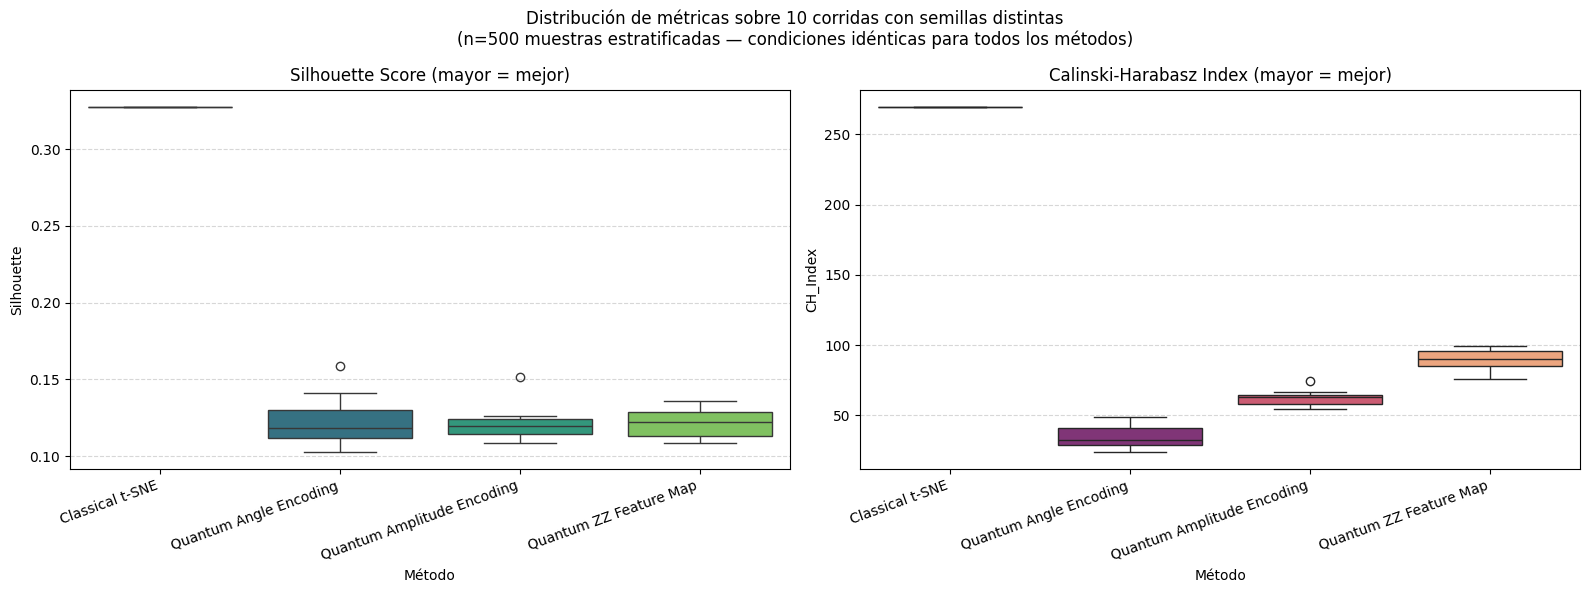

In [13]:
# ── Visualización estadística — boxplots por método ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Distribución de métricas sobre {N_RUNS} corridas con semillas distintas\n'
    f'(n={N_SAMPLES} muestras estratificadas — condiciones idénticas para todos los métodos)',
    fontsize=12
)

order = df_stats.sort_values('Sil_mean', ascending=False)['Método'].tolist()

sns.boxplot(data=df_runs, x='Método', y='Silhouette',
            order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Silhouette Score (mayor = mejor)')
axes[0].set_xticklabels([m.split('(')[0].strip() for m in order], rotation=20, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df_runs, x='Método', y='CH_Index',
            order=order, palette='magma', ax=axes[1])
axes[1].set_title('Calinski-Harabasz Index (mayor = mejor)')
axes[1].set_xticklabels([m.split('(')[0].strip() for m in order], rotation=20, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Visualización de Embeddings (Mediana de Silhouette)

Para visualización mostramos el run cuya métrica Silhouette es la **mediana** de las
N_RUNS corridas — evitando mostrar el mejor o peor caso.

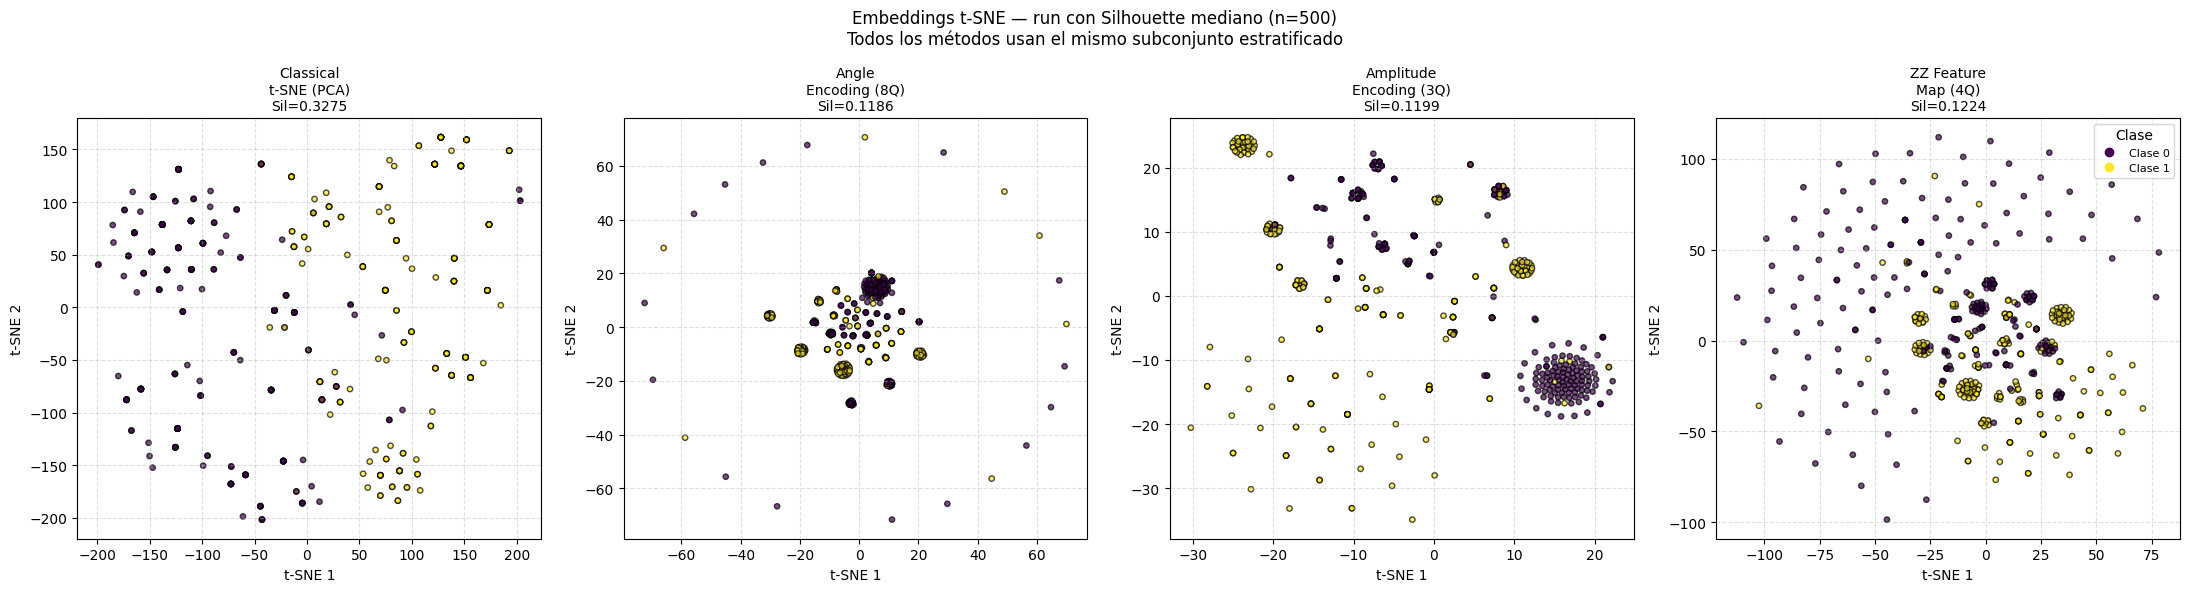

In [14]:
def get_median_run_embedding(method_name):
    """Retorna el embedding del run con Silhouette más cercano a la mediana."""
    subset = df_runs[df_runs['Método'] == method_name].copy()
    median_sil = subset['Silhouette'].median()
    idx = (subset['Silhouette'] - median_sil).abs().idxmin()
    return subset.loc[idx, 'embedding']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Embeddings t-SNE — run con Silhouette mediano (n={N_SAMPLES})\n'
    'Todos los métodos usan el mismo subconjunto estratificado',
    fontsize=12
)

for ax, (mname, cfg) in zip(axes, method_configs.items()):
    emb = get_median_run_embedding(mname)
    sil_med = df_runs[df_runs['Método']==mname]['Silhouette'].median()
    plot_embedding(ax, emb, y, f"{cfg['label']}\nSil={sil_med:.4f}")

# Leyenda de clases
unique_cls = np.unique(y)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_cls)))
handles = [mlines.Line2D([],[],color=c,marker='o',linestyle='None',label=f'Clase {cl}')
           for c, cl in zip(colors, unique_cls)]
axes[-1].legend(handles=handles, title='Clase', loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Análisis de Variabilidad entre Corridas

La variabilidad (std de Silhouette) es un indicador de estabilidad del embedding.
Un método con alta variabilidad es menos confiable para investigación.

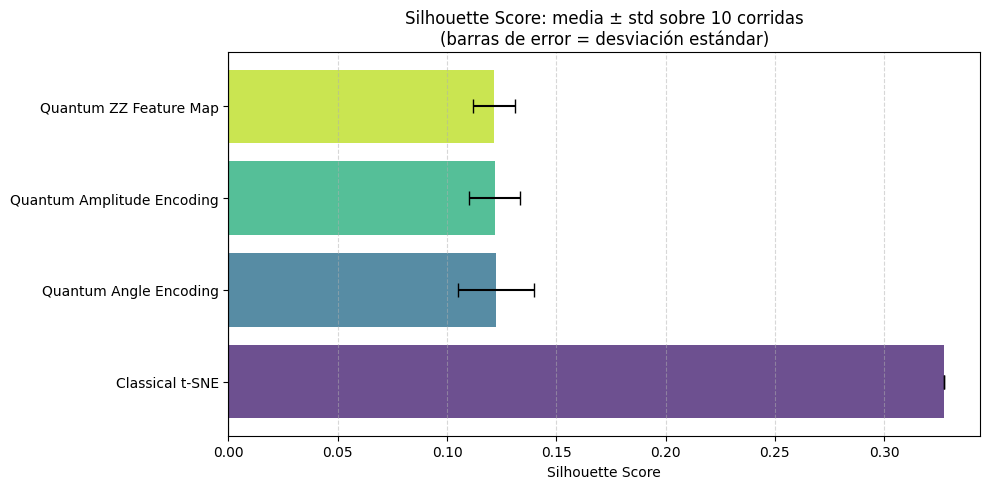


Tabla de variabilidad (std menor = más estable):


,Método,Sil_mean,Sil_std
0,Classical t-SNE (PCA-6D),0.327514,0.000000
3,Quantum ZZ Feature Map (4Q),0.121339,0.009545
1,Quantum Amplitude Encoding (3Q),0.121792,0.011808
2,Quantum Angle Encoding (8Q),0.122473,0.017509


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

df_stats_sorted = df_stats.sort_values('Sil_mean', ascending=False)

x_pos = np.arange(len(df_stats_sorted))
labels_short = [m.split('(')[0].strip() for m in df_stats_sorted['Método']]

bars = ax.barh(x_pos, df_stats_sorted['Sil_mean'],
               xerr=df_stats_sorted['Sil_std'],
               align='center', alpha=0.8, capsize=5,
               color=plt.cm.viridis(np.linspace(0.1, 0.9, len(df_stats_sorted))))

ax.set_yticks(x_pos)
ax.set_yticklabels(labels_short)
ax.set_xlabel('Silhouette Score')
ax.set_title(f'Silhouette Score: media ± std sobre {N_RUNS} corridas\n(barras de error = desviación estándar)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nTabla de variabilidad (std menor = más estable):")
display(df_stats[['Método','Sil_mean','Sil_std']].sort_values('Sil_std'))

## 10. Sensibilidad a la Perplejidad

Evaluamos cómo varía el Silhouette Score en función de la perplejidad para cada
método. Cada punto es la media sobre N_RUNS corridas.

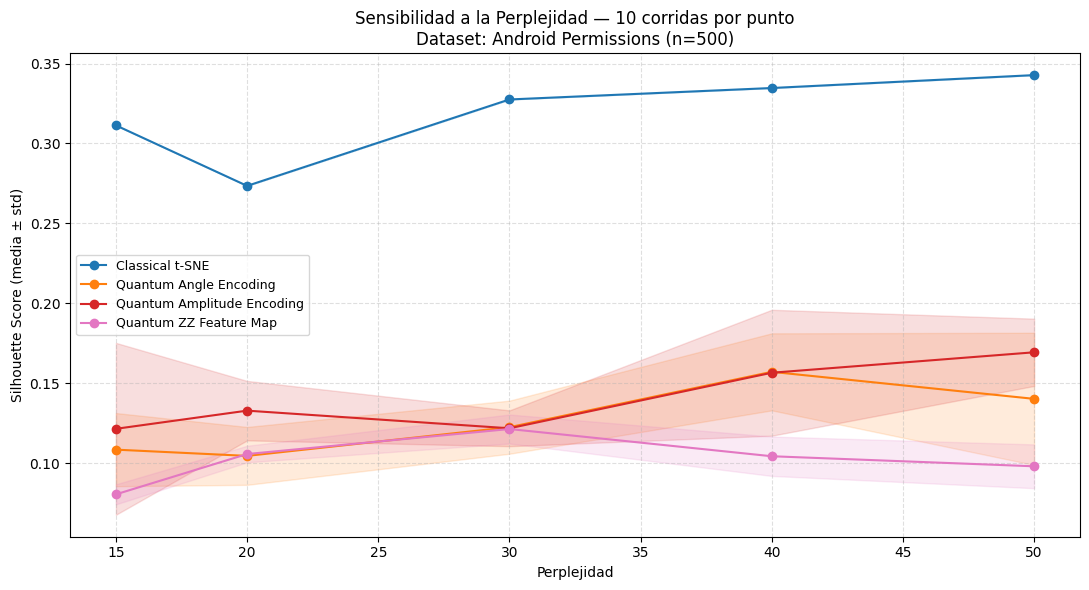

In [16]:
PERPLEXITIES = [15, 20, 30, 40, 50]

perp_results = {m: [] for m in method_configs}

for perp in PERPLEXITIES:
    for mname, cfg in method_configs.items():
        sils = []
        for seed in SEEDS:
            if cfg['type'] == 'classical':
                emb = TSNE(n_components=2, perplexity=perp,
                           random_state=seed, n_jobs=1).fit_transform(cfg['X'])
            else:
                emb = run_tsne_from_kernel(cfg['K'], perplexity=perp, seed=seed)
            sils.append(silhouette_score(emb, y))
        perp_results[mname].append({'perp': perp,
                                    'mean': np.mean(sils),
                                    'std':  np.std(sils)})

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
colors_map = plt.cm.tab10(np.linspace(0, 0.6, len(method_configs)))

for color, (mname, records) in zip(colors_map, perp_results.items()):
    perps = [r['perp'] for r in records]
    means = [r['mean'] for r in records]
    stds  = [r['std']  for r in records]
    label = mname.split('(')[0].strip()
    ax.plot(perps, means, marker='o', label=label, color=color)
    ax.fill_between(perps,
                    [m-s for m,s in zip(means,stds)],
                    [m+s for m,s in zip(means,stds)],
                    alpha=0.15, color=color)

ax.set_xlabel('Perplejidad')
ax.set_ylabel('Silhouette Score (media ± std)')
ax.set_title(f'Sensibilidad a la Perplejidad — {N_RUNS} corridas por punto\n'
             f'Dataset: Android Permissions (n={N_SAMPLES})')
ax.legend(loc='best', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 11. Visualización de los Circuitos Cuánticos Utilizados

Los circuitos a continuación son los que se ejecutan mediante Statevector
para calcular cada entrada de las matrices de kernel.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.


--- Angle Encoding (8 qubits) ---
Gates: OrderedDict([('ry', 8)])


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


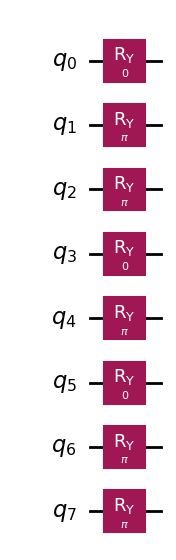


--- Amplitude Encoding (3 qubits) ---
Profundidad descompuesto: 1, Gates: OrderedDict([('isometry_to_uncompute_dg', 1)])


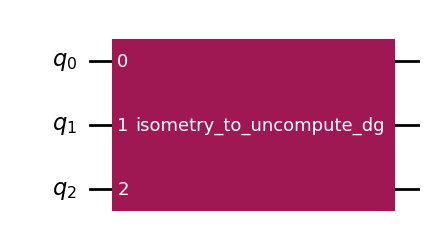


--- ZZ Feature Map (4 qubits, reps=2) ---
Profundidad: 31, Gates: OrderedDict([('cx', 24), ('p', 20), ('h', 8)])


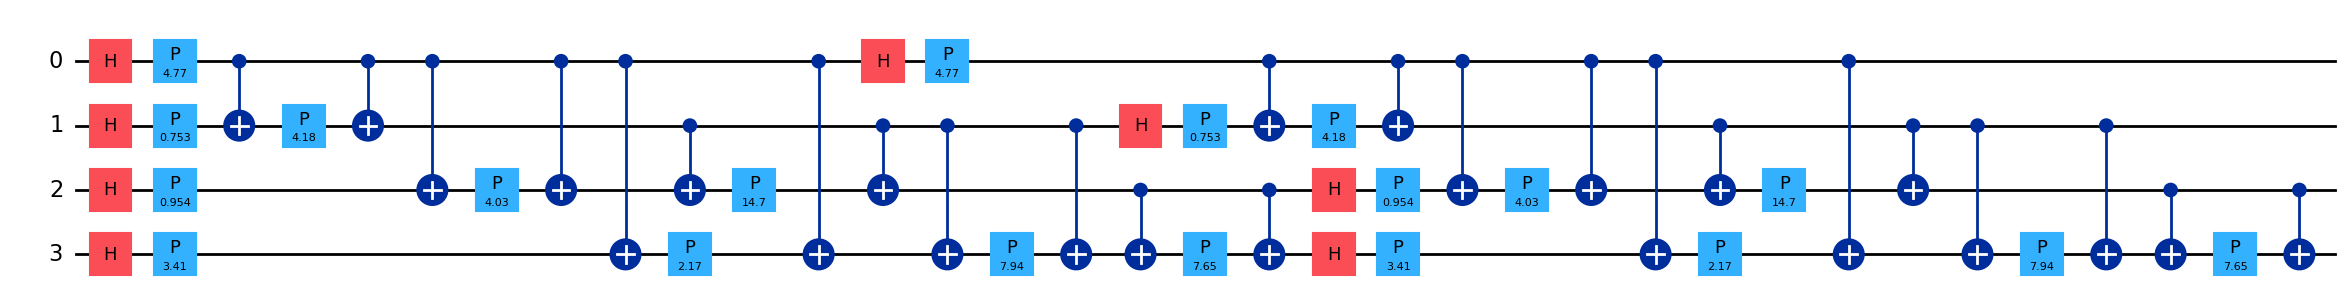

In [17]:
sample = X_angles[0]

# Angle circuit
qc_angle_vis = build_angle_circuit(sample)
print(f"--- Angle Encoding ({len(sample)} qubits) ---")
print(f"Gates: {qc_angle_vis.count_ops()}")
try:   display(qc_angle_vis.draw('mpl', style='iqp'))
except: print(qc_angle_vis.draw())

# Amplitude circuit
qc_amp_vis = build_amplitude_circuit(X_amp[0])
qc_amp_decomp = qc_amp_vis.decompose()
print(f"\n--- Amplitude Encoding ({n_system_qubits} qubits) ---")
print(f"Profundidad descompuesto: {qc_amp_decomp.depth()}, Gates: {qc_amp_decomp.count_ops()}")
try:   display(qc_amp_decomp.draw('mpl', style='iqp'))
except: print(qc_amp_decomp.draw())

# ZZ circuit
qc_zz_vis = build_zz_circuit(X_zz[0], n_qubits=N_QUBITS_ZZ)
print(f"\n--- ZZ Feature Map ({N_QUBITS_ZZ} qubits, reps=2) ---")
print(f"Profundidad: {qc_zz_vis.depth()}, Gates: {qc_zz_vis.count_ops()}")
try:   display(qc_zz_vis.draw('mpl', style='iqp', fold=60))
except: print(qc_zz_vis.draw())

## 12. Resumen y Conclusiones

### Correcciones metodológicas aplicadas

| Punto | Problema original | Solución implementada |
|-------|-------------------|----------------------|
| **1** | Kernels calculados con NumPy — sin simulación cuántica real | Kernels via `Statevector` de Qiskit — mecánica cuántica exacta |
| **5** | Un único run con `random_state=42` — sin análisis estadístico | N_RUNS corridas con semillas distintas — media ± std reportados |
| **6** | Clásico sobre PCA-6D vs cuántico sobre datos completos — comparación injusta | Todos los métodos sobre el mismo subconjunto estratificado de n=500 |

### Limitaciones y trabajo futuro
- Los kernels ZZ/Angle/Amplitude son matemáticamente equivalentes a sus contrapartes clásicas en simulación; la ventaja cuántica real solo emerge en hardware cuántico con d > ~50 qubits.
- El dataset binario (permisos 0/1) limita la expresividad del Angle Encoding; features continuas post-PCA son más apropiadas para el ZZ Feature Map.
- Trabajo futuro: evaluar accuracy downstream (clasificador sobre embedding) y escalar a hardware real via IBM Quantum o Amazon Braket.

In [ ]:
print("=" * 60)
print("RESUMEN FINAL — Wine Dataset (UCI 109)")
print("=" * 60)
print(f"  Muestras usadas : {N_SAMPLES} (estratificado de {X_full.shape[0]})")
print(f"  Features        : {X_full.shape[1]}")
print(f"  Clases          : {len(np.unique(y))} variedades de vino")
print(f"  Corridas t-SNE  : {N_RUNS} por método")
print()
display(
    df_stats[['Método', 'Sil_mean', 'Silhouette (mean±std)',
              'CH Index (mean±std)', 'DB Index (mean±std)']]
    .sort_values('Sil_mean', ascending=False)
    .drop(columns=['Sil_mean'])
    .reset_index(drop=True)
)